# Análise dos resultados — Trabalho 4 (Link Extractor)

Este notebook consolida os CSVs gerados pelo Locust em `results/raw/`,
produz a planilha `results/processed/consolidado.xlsx` e gera os gráficos
comparativos em `results/charts/`.

**Pré-requisito**: ter rodado `scripts/run-all-scenarios.ps1` (ou cenários
individuais) para popular `results/raw/`.

**Como executar**:
```powershell
.\.venv\Scripts\jupyter.exe lab analysis/analise.ipynb
```
ou abra em VSCode com a extensão Jupyter.

## 1. Imports e caminhos

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
RAW = ROOT / "results" / "raw"
PROCESSED = ROOT / "results" / "processed"
CHARTS = ROOT / "results" / "charts"
PROCESSED.mkdir(parents=True, exist_ok=True)
CHARTS.mkdir(parents=True, exist_ok=True)

print(f"ROOT      = {ROOT}")
print(f"RAW       = {RAW}")
print(f"PROCESSED = {PROCESSED}")
print(f"CHARTS    = {CHARTS}")
print(f"\nCSVs encontrados em raw: {len(list(RAW.glob('*_stats.csv')))}")

ROOT      = c:\Users\User\Documents\linkextractor-loadtest
RAW       = c:\Users\User\Documents\linkextractor-loadtest\results\raw
PROCESSED = c:\Users\User\Documents\linkextractor-loadtest\results\processed
CHARTS    = c:\Users\User\Documents\linkextractor-loadtest\results\charts

CSVs encontrados em raw: 12


## 2. Consolidação dos CSVs do Locust

Cada cenário gera 4 arquivos com prefixo `<version>_<cache>_<users>u_<runtime>`.
Vamos extrair a linha `Aggregated` de cada `*_stats.csv` para montar a aba
`resumo`, e juntar todos os `*_stats_history.csv` na aba `series`.

In [2]:
NAME_RE = re.compile(
    r"^(?P<version>python|ruby)_(?P<cache>warm|cold)_(?P<users>\d+)u_(?P<runtime>[^_]+)_stats\.csv$"
)

def parse_tag(filename: str):
    m = NAME_RE.match(filename)
    if not m:
        return None
    return {
        "version": m.group("version"),
        "cache": m.group("cache"),
        "users": int(m.group("users")),
        "runtime": m.group("runtime"),
    }

rows = []
for csv in sorted(RAW.glob("*_stats.csv")):
    tag = parse_tag(csv.name)
    if tag is None:
        continue
    df = pd.read_csv(csv)
    agg = df[df["Name"] == "Aggregated"]
    if agg.empty:
        agg = df.tail(1)
    r = agg.iloc[0].to_dict()
    rows.append({
        **tag,
        "requests": int(r.get("Request Count", 0)),
        "failures": int(r.get("Failure Count", 0)),
        "rps": r.get("Requests/s", float("nan")),
        "mean_ms": r.get("Average Response Time", float("nan")),
        "median_ms": r.get("Median Response Time", float("nan")),
        "p95_ms": r.get("95%", float("nan")),
        "p99_ms": r.get("99%", float("nan")),
        "min_ms": r.get("Min Response Time", float("nan")),
        "max_ms": r.get("Max Response Time", float("nan")),
    })

if not rows:
    raise RuntimeError("Nenhum *_stats.csv em results/raw/. Rode os cenários antes.")

resumo = pd.DataFrame(rows).sort_values(["version", "cache", "users"]).reset_index(drop=True)
resumo

,version,cache,users,runtime,requests,failures,rps,mean_ms,median_ms,p95_ms,p99_ms,min_ms,max_ms
0,python,cold,10,2m,2188,0,18.416152,432.026704,380,840,1100,68.7634,1758.7952
1,python,cold,50,2m,4082,234,34.399475,1327.236424,1200,2900,3600,2.3347,4565.3137
2,python,cold,100,2m,3967,6,33.458120,2808.855444,2500,5000,6900,21.5650,8565.6710
3,python,warm,10,2m,10820,0,91.031876,8.612432,6,13,21,3.4219,1011.1815
4,python,warm,50,2m,36785,10216,309.334537,58.771935,45,110,200,2.2547,2974.7343
5,python,warm,100,2m,44902,20,378.054090,158.409409,110,240,830,19.2937,7779.0805
6,ruby,cold,10,2m,2189,189,18.419820,437.345731,410,860,1000,28.1254,3718.1868
7,ruby,cold,50,2m,5575,1157,46.977920,948.075312,890,1800,2300,54.5988,5196.4593
8,ruby,cold,100,2m,5617,1175,47.269661,1961.861149,1700,4400,6300,79.0145,10092.8280
9,ruby,warm,10,2m,11110,0,93.593727,5.079103,3,7,10,1.8673,743.8736


In [3]:
frames = []
for csv in sorted(RAW.glob("*_stats_history.csv")):
    base = csv.name.replace("_stats_history.csv", "_stats.csv")
    tag = parse_tag(base)
    if tag is None:
        continue
    df = pd.read_csv(csv)
    for k, v in tag.items():
        df[k] = v
    frames.append(df)

series = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"Linhas na série temporal consolidada: {len(series)}")
series.head()

Linhas na série temporal consolidada: 1392


,Timestamp,User Count,Type,Name,Requests/s,Failures/s,50%,66%,75%,80%,...,Total Failure Count,Total Median Response Time,Total Average Response Time,Total Min Response Time,Total Max Response Time,Total Average Content Size,version,cache,users,runtime
0,1778465568,0,NaN,Aggregated,0.0,0.0,NaN,NaN,NaN,NaN,...,0,0.0,0.000000,0.0000,0.0000,0.000000,python,cold,100,2m
1,1778465569,20,NaN,Aggregated,0.0,0.0,800.0,810.0,820.0,820.0,...,0,790.0,780.442920,689.6409,829.3404,84.000000,python,cold,100,2m
2,1778465570,40,NaN,Aggregated,0.0,0.0,720.0,790.0,810.0,820.0,...,0,700.0,699.861976,475.4438,979.6001,1320.086957,python,cold,100,2m
3,1778465571,60,NaN,Aggregated,0.0,0.0,830.0,1200.0,1200.0,1200.0,...,0,830.0,930.020053,331.9882,1587.1720,5709.829545,python,cold,100,2m
4,1778465572,100,NaN,Aggregated,20.0,0.0,830.0,1200.0,1200.0,1200.0,...,0,830.0,943.090851,331.9882,1716.9729,5629.072165,python,cold,100,2m


## 3. Salvar a planilha consolidada

In [4]:
out_path = PROCESSED / "consolidado.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as w:
    resumo.to_excel(w, sheet_name="resumo", index=False)
    if not series.empty:
        series.to_excel(w, sheet_name="series", index=False)

print(f"Salvo: {out_path}")

Salvo: c:\Users\User\Documents\linkextractor-loadtest\results\processed\consolidado.xlsx


## 4. Gráficos

Cada gráfico compara as quatro combinações `versao/cache` ao longo dos
níveis de carga (10, 50, 100 usuários).

In [5]:
def line_by_users(df, metric, ylabel, title, fname):
    fig, ax = plt.subplots(figsize=(8, 5))
    for (version, cache), grp in df.groupby(["version", "cache"]):
        grp = grp.sort_values("users")
        ax.plot(grp["users"], grp[metric], marker="o", label=f"{version} / {cache}")
    ax.set_xlabel("Usuários virtuais")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    out = CHARTS / fname
    fig.savefig(out, dpi=120)
    plt.show()
    print(f"  salvo: {out}")

### 4.1. Tempo médio de resposta

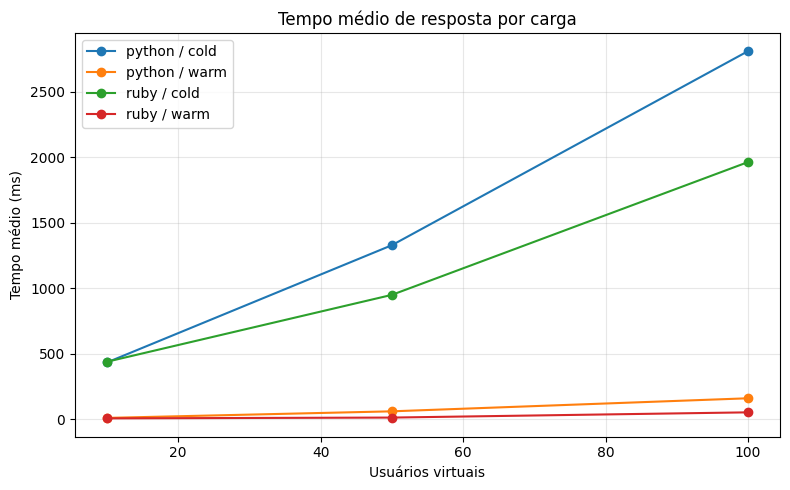

  salvo: c:\Users\User\Documents\linkextractor-loadtest\results\charts\tempo_resposta_por_carga.png


In [6]:
line_by_users(resumo, "mean_ms", "Tempo médio (ms)",
              "Tempo médio de resposta por carga",
              "tempo_resposta_por_carga.png")

### 4.2. Mediana

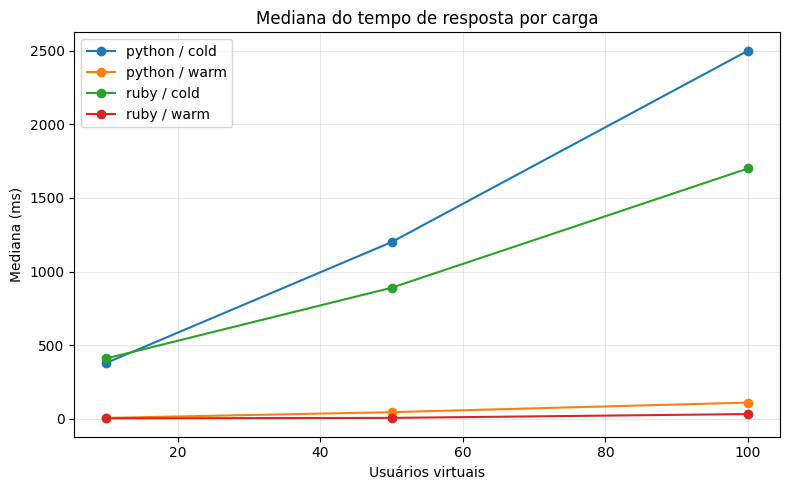

  salvo: c:\Users\User\Documents\linkextractor-loadtest\results\charts\mediana_por_carga.png


In [7]:
line_by_users(resumo, "median_ms", "Mediana (ms)",
              "Mediana do tempo de resposta por carga",
              "mediana_por_carga.png")

### 4.3. Percentil 95

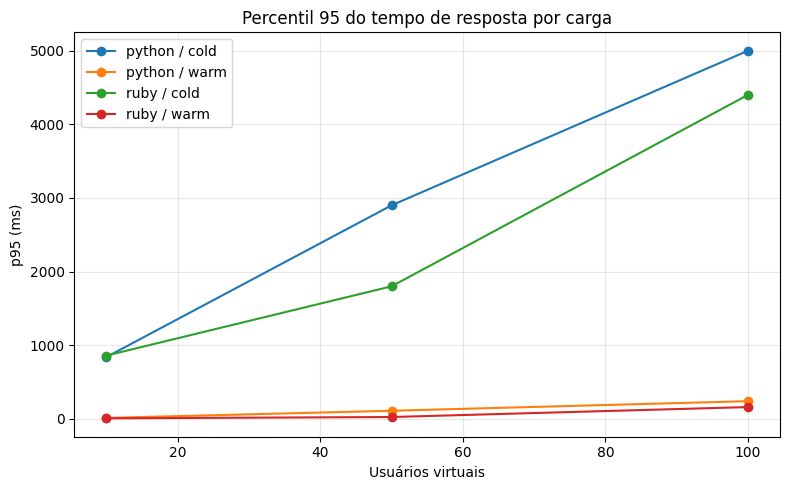

  salvo: c:\Users\User\Documents\linkextractor-loadtest\results\charts\p95_por_carga.png


In [8]:
line_by_users(resumo, "p95_ms", "p95 (ms)",
              "Percentil 95 do tempo de resposta por carga",
              "p95_por_carga.png")

### 4.4. Percentil 99

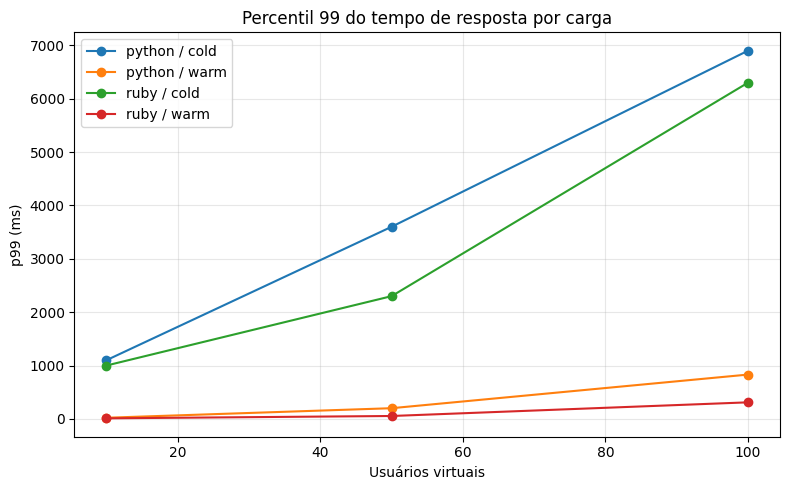

  salvo: c:\Users\User\Documents\linkextractor-loadtest\results\charts\p99_por_carga.png


In [9]:
line_by_users(resumo, "p99_ms", "p99 (ms)",
              "Percentil 99 do tempo de resposta por carga",
              "p99_por_carga.png")

### 4.5. Throughput (RPS)

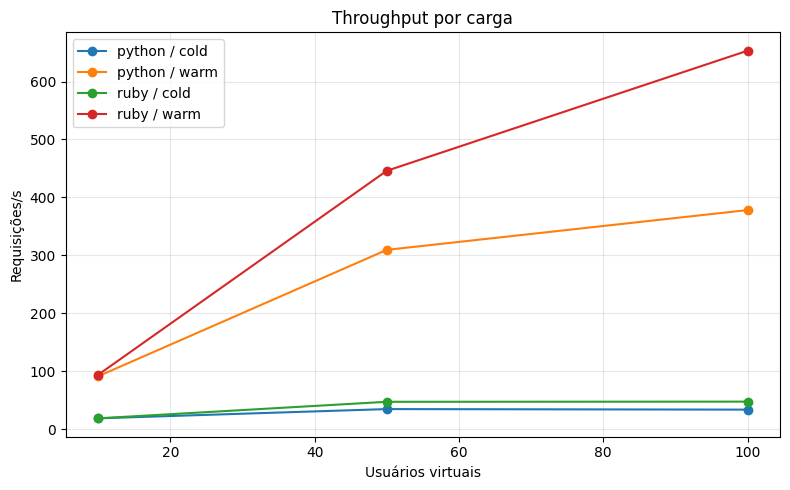

  salvo: c:\Users\User\Documents\linkextractor-loadtest\results\charts\throughput_por_carga.png


In [10]:
line_by_users(resumo, "rps", "Requisições/s",
              "Throughput por carga",
              "throughput_por_carga.png")

### 4.6. Falhas por cenário

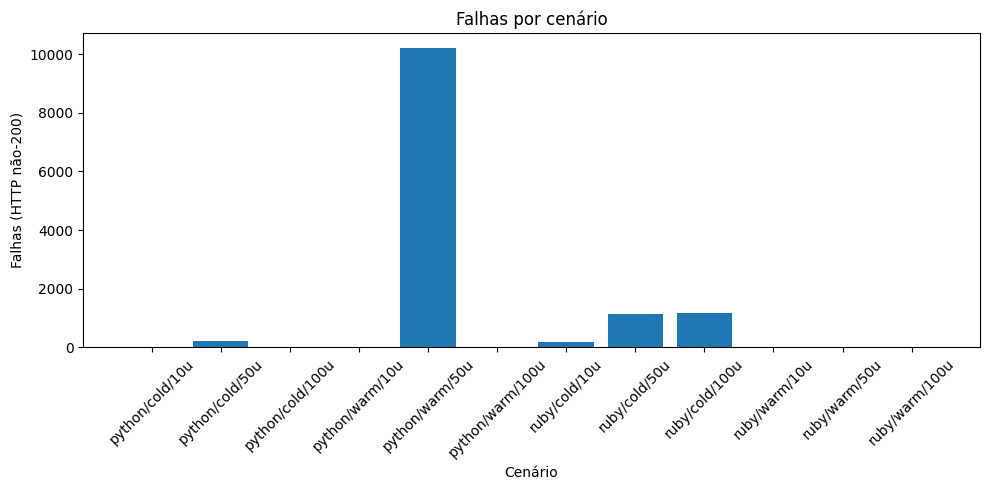

  salvo: c:\Users\User\Documents\linkextractor-loadtest\results\charts\falhas_por_cenario.png


In [11]:
df = resumo.copy()
df["scenario"] = df["version"] + "/" + df["cache"] + "/" + df["users"].astype(str) + "u"
df = df.sort_values(["version", "cache", "users"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df["scenario"], df["failures"])
ax.set_xlabel("Cenário")
ax.set_ylabel("Falhas (HTTP não-200)")
ax.set_title("Falhas por cenário")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
out = CHARTS / "falhas_por_cenario.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"  salvo: {out}")

## 5. Observações finais

Use esta seção para anotar conclusões durante a análise:

- Qual versão (Python ou Ruby) tem **menor latência média** e por que.
- Quão grande é o ganho do cache (warm vs cold) em cada versão.
- A partir de qual nível de carga começam falhas e em qual combinação.
- Diferença entre **mediana e p99** — se p99 cresce muito mais rápido,
  há cauda longa (alguns clientes esperam muito mais que a maioria).
- Como o **throughput satura** com o aumento de usuários — se a curva
  achata, atingimos o limite do serviço.